# Analysis of H3

## Hypothesis 3
Shifts in feminist theoretical orientation within Heresies will coincide with changes in patterns of contribution, including the emergence of new contributors and changing thematic emphases associated with the magazine's rotating collectives.


### Analysis

1. Overall contributor frequency — ranks the top 20 contributors across all issues (Su Friedrich, Joan Braderman, Mary Beth Edelson lead). Gives a baseline picture of who dominated the magazine overall.

2. Contributor frequency per volume and per issue — line charts tracking how often the top 10 contributors appear across each volume and each individual issue. Shows whether core contributors are consistent across the run or concentrated in specific periods.

3. New contributor emergence — calculates each person's first appearance, then counts how many new contributors debuted per volume and per issue. Reveals clear waves of renewal (biggest spike: issue 17 with 122 new contributors), directly evidencing the rotating collective model.

4. Contributors unique to one volume/issue — counts how many people appeared only once (1,610 unique to one volume; 1,592 unique to one issue), showing high turnover and a largely non-recurring contributor base.

5. Collective membership analyses — uses the collective_strucutre XML region to:

- extract names from collective text per volume using NER (en_core_web_trf)
- track collective membership size per volume
- track new collective members per volume
- measure overlap between collective members and contributors (46 overlap — collective members and public contributors were largely separate roles)



### Sources
- Bar Plot in Matplotlib—GeeksforGeeks. (n.d.). Retrieved May 29, 2026, from https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/


### 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

### 2. Loading Dataset

In [2]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/07_h3_contributors.csv")
print(df.shape)
print(df["volume"].value_counts())

(2360, 5)
volume
Vol1_1977-1978    429
Vol4_1981-1983    404
Vol3_1980-1981    377
Vol5_1984-1985    363
Vol2_1978-1979    295
Vol6_1987-1989    257
Vol7_1990-1993    235
Name: count, dtype: int64


### 3. Helper functions

In [3]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:    return "Vol1_1977-1978"
    elif issue_nr <= 8:  return "Vol2_1978-1979"
    elif issue_nr <= 12: return "Vol3_1980-1981"
    elif issue_nr <= 16: return "Vol4_1981-1983"
    elif issue_nr <= 20: return "Vol5_1984-1985"
    elif issue_nr <= 24: return "Vol6_1987-1989"
    elif issue_nr <= 27: return "Vol7_1990-1993"
    else: return None

vol_order = [
    "Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981", "Vol4_1981-1983",
    "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"
]

### 4. Overall Contributor Frequency
Using this: https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/

In [4]:
overall_freq = df["person"].value_counts().head(20)
print(overall_freq)

person
Su Friedrich         12
JOAN BRADERMAN       11
Mary Beth Edelson     9
Ana Mendieta          8
Lyn Hughes            7
Lucy R. Lippard       7
Sondra Segal          7
Amy Sillman           6
hattie gossett        6
Margaret Randall      6
eeva-inkeri           6
Carolien Stikker      6
Howardena Pindell     5
Vivian E. Browne      5
May Stevens           5
Lis Rhodes            5
Diana Agosta          5
Susan Kleckner        5
Dee Shapiro           5
Ann Wilson            5
Name: count, dtype: int64


### 5. Graph 1: Top Contributors Overall

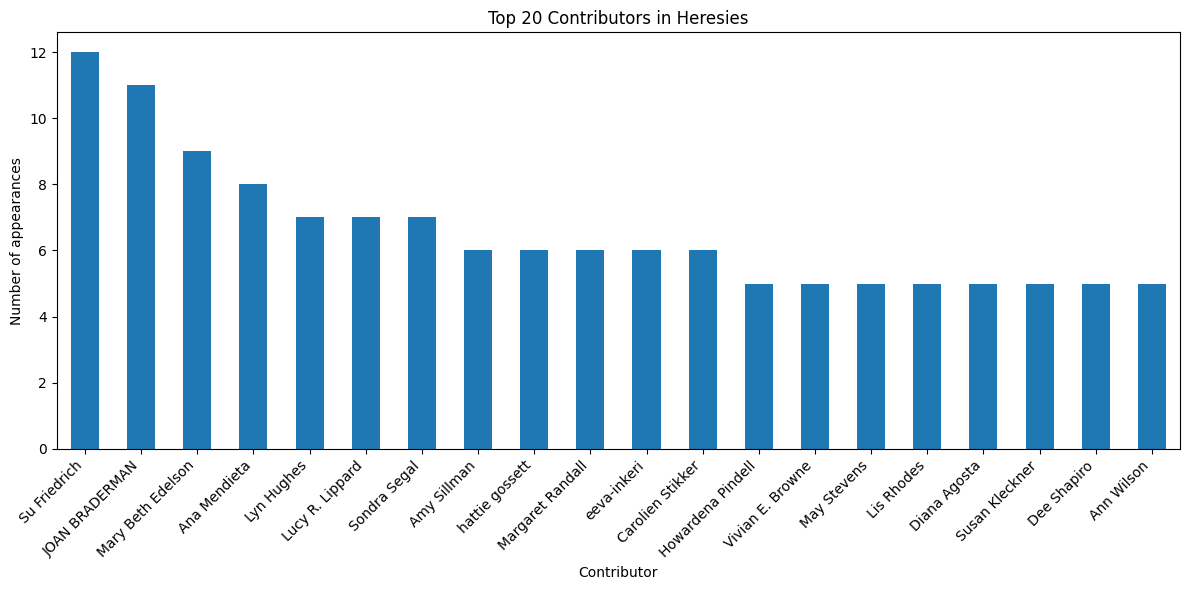

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
overall_freq.plot(kind="bar", ax=ax)
ax.set_xlabel("Contributor")
ax.set_ylabel("Number of appearances")
ax.set_title("Top 20 Contributors in Heresies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_overall_frequency.png")
plt.show()

### 6. Contributor Frequency per Volume

In [6]:
volume_freq = df.groupby(["volume", "person"]).size().reset_index(name="count")
print(volume_freq.head(20))

            volume                   person  count
0   Vol1_1977-1978            -JOANNE LEONA      1
1   Vol1_1977-1978            ADRIENNE RICH      1
2   Vol1_1977-1978           ANN LAUTERBACH      1
3   Vol1_1977-1978            ARDELE LISTER      1
4   Vol1_1977-1978           Adelaide Alsop      1
5   Vol1_1977-1978  Adelaide Alsop Robineau      1
6   Vol1_1977-1978           Adele Blumberg      1
7   Vol1_1977-1978            Adrienne Rich      2
8   Vol1_1977-1978                 Al Mozeh      1
9   Vol1_1977-1978             Alain Klarer      2
10  Vol1_1977-1978     Alexandra Kollantai.      1
11  Vol1_1977-1978             Alice Austen      3
12  Vol1_1977-1978             Alice Aycock      1
13  Vol1_1977-1978          Alice B. Toklas      1
14  Vol1_1977-1978      Alice Watters Beebe      2
15  Vol1_1977-1978             Alma Buscher      1
16  Vol1_1977-1978              Amy Sillman      6
17  Vol1_1977-1978                Anaïs Nin      2
18  Vol1_1977-1978           An

### 7. Graph 2: Top Contributors per Volume

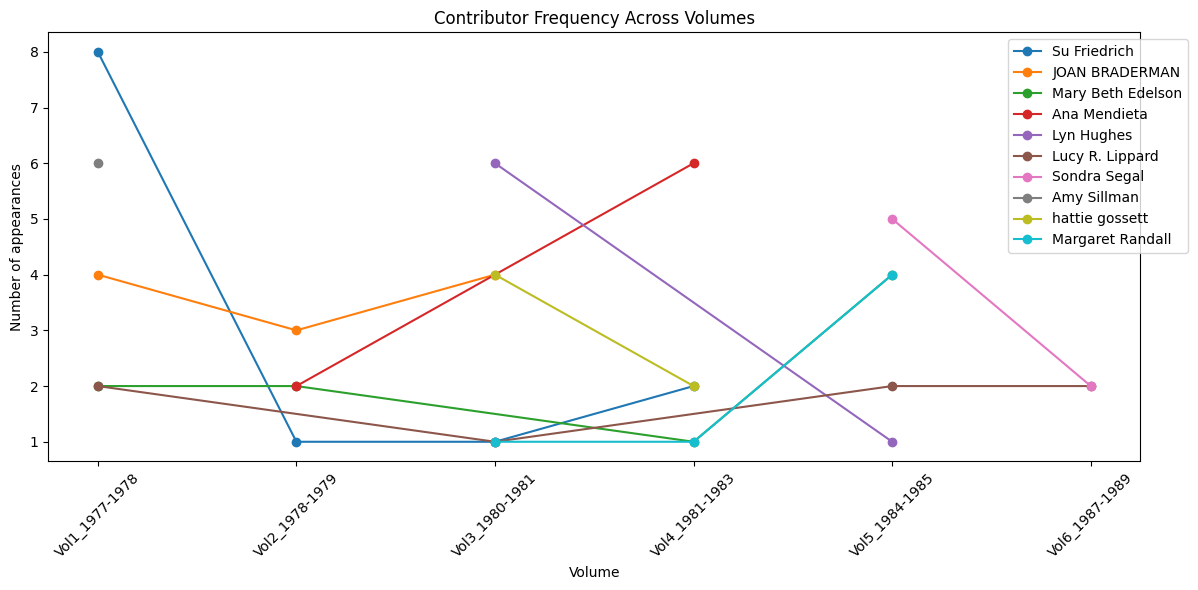

In [7]:
top_contributors = df["person"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for person in top_contributors:
    person_data = volume_freq[volume_freq["person"] == person]
    ax.plot(person_data["volume"], person_data["count"], marker="o", label=person)

ax.set_xlabel("Volume")
ax.set_ylabel("Number of appearances")
ax.set_title("Contributor Frequency Across Volumes")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_volume_frequency.png")
plt.show()

### 8. Graph 3: Top Contributors per Issue

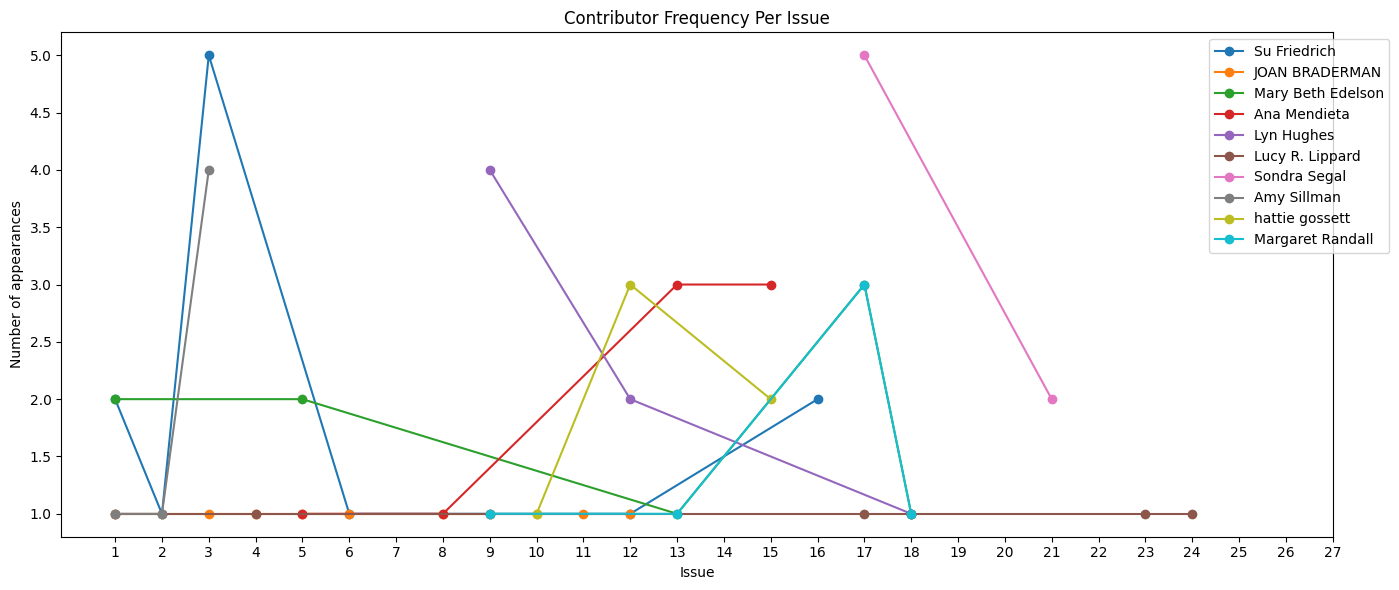

In [8]:
issue_freq = df.groupby(["issue", "person"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(14, 6))

for person in top_contributors:
    person_data = issue_freq[issue_freq["person"] == person]
    ax.plot(person_data["issue"], person_data["count"], marker="o", label=person)

ax.set_xlabel("Issue")
ax.set_ylabel("Number of appearances")
ax.set_title("Contributor Frequency Per Issue")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(range(1, 28))
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_issue_frequency.png")
plt.show()

### 9. New Contributors per Volume and Issue

In [9]:
# find the first issue each contributor ever appeared in
first_appearance = df.groupby("person")["issue"].min().reset_index()
first_appearance.columns = ["person", "first_issue"]
first_appearance["first_volume"] = first_appearance["first_issue"].apply(get_volume)

# count new contributors per volume
new_per_volume = first_appearance["first_volume"].value_counts()
new_per_volume = new_per_volume.reindex([v for v in vol_order if v in new_per_volume.index])

print("New contributors per volume:")
print(new_per_volume)

# count new contributors per issue
new_per_issue = first_appearance["first_issue"].value_counts().sort_index()
print("\nNew contributors per issue:")
print(new_per_issue)

New contributors per volume:
first_volume
Vol1_1977-1978    346
Vol2_1978-1979    232
Vol3_1980-1981    248
Vol4_1981-1983    286
Vol5_1984-1985    252
Vol6_1987-1989    206
Vol7_1990-1993    183
Name: count, dtype: int64

New contributors per issue:
first_issue
1      62
2     100
3      88
4      96
5      84
6      49
7      34
8      65
9      29
10     93
11     60
12     66
13     95
14      8
15     98
16     85
17    123
18     45
19     32
20     52
21     61
22     62
23     50
24     33
25     53
26     41
27     89
Name: count, dtype: int64


### 10. Graph 4: New Contributors per Volume

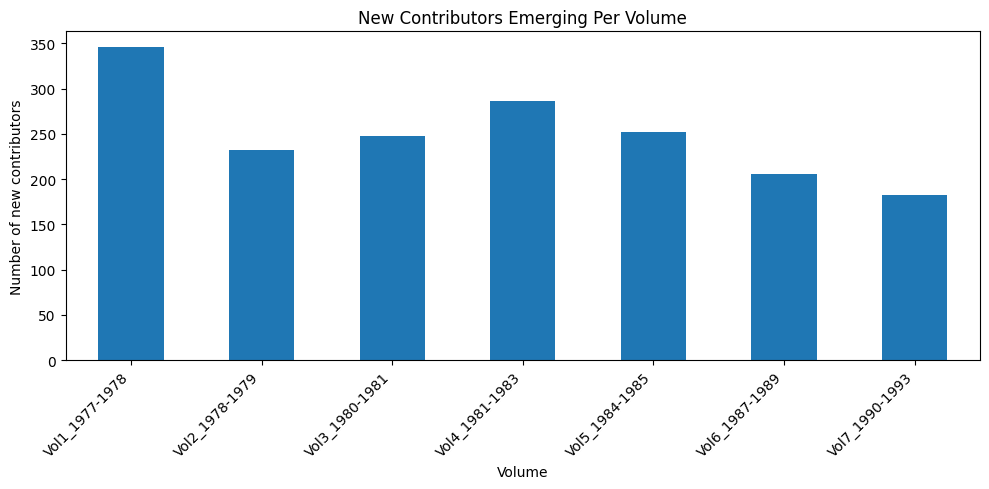

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
new_per_volume.plot(kind="bar", ax=ax)
ax.set_xlabel("Volume")
ax.set_ylabel("Number of new contributors")
ax.set_title("New Contributors Emerging Per Volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_contributors_volume.png")
plt.show()

### 11. Graph 5: New Contributors per Issue

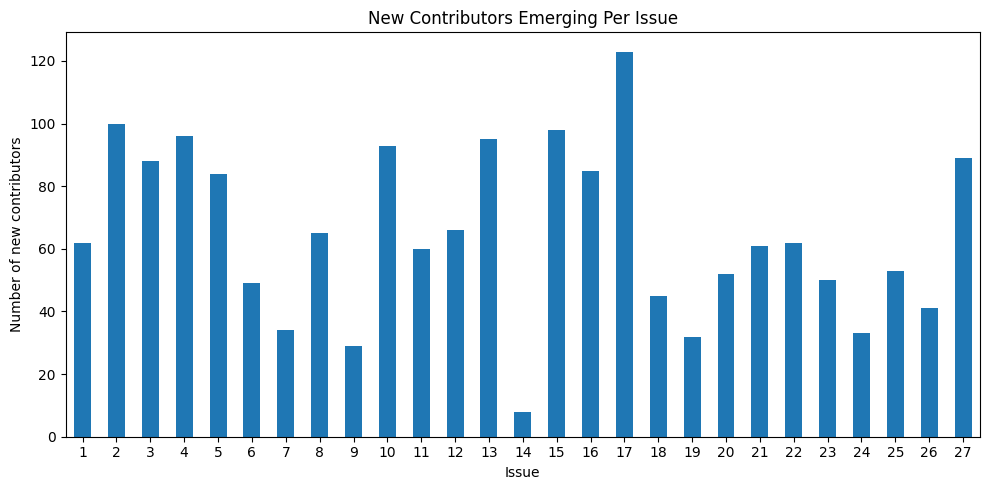

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
new_per_issue.plot(kind="bar", ax=ax)
ax.set_xlabel("Issue")
ax.set_ylabel("Number of new contributors")
ax.set_title("New Contributors Emerging Per Issue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_contributors_issue.png")
plt.show()

### 12. Contributors Unique to One Volume or Issue

In [12]:
# contributors who appear in only one volume
volume_count = df.groupby("person")["volume"].nunique().reset_index()
volume_count.columns = ["person", "volumes_active"]

unique_contributors = volume_count[volume_count["volumes_active"] == 1]
print(f"Contributors appearing in only one volume: {len(unique_contributors)}")

unique_with_volume = unique_contributors.merge(first_appearance[["person", "first_volume"]], on="person")
print(unique_with_volume["first_volume"].value_counts())

# contributors who appear in only one issue
issue_count = df.groupby("person")["issue"].nunique().reset_index()
issue_count.columns = ["person", "issues_active"]

unique_issue = issue_count[issue_count["issues_active"] == 1]
print(f"\nContributors appearing in only one issue: {len(unique_issue)}")

unique_with_issue = unique_issue.merge(first_appearance[["person", "first_issue"]], on="person")
print(unique_with_issue["first_issue"].value_counts().sort_index())

Contributors appearing in only one volume: 1648
first_volume
Vol1_1977-1978    298
Vol4_1981-1983    272
Vol5_1984-1985    241
Vol3_1980-1981    236
Vol2_1978-1979    217
Vol6_1987-1989    201
Vol7_1990-1993    183
Name: count, dtype: int64

Contributors appearing in only one issue: 1631
first_issue
1      42
2      85
3      77
4      87
5      79
6      46
7      32
8      58
9      27
10     92
11     60
12     57
13     88
14      6
15     92
16     83
17    118
18     42
19     31
20     47
21     59
22     59
23     50
24     31
25     53
26     41
27     89
Name: count, dtype: int64


### 13. Load Collective Membership Data
Note: there is a typo in the XML tag — "collective_strucutre" not "collective_structure"

In [13]:
df_corpus = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/01_parsed_corpus.csv")

df_collective = df_corpus[df_corpus["region_type"] == "collective_strucutre"].copy()

df_collective["issue"]  = df_collective["source_file"].apply(get_issue_number)
df_collective["volume"] = df_collective["issue"].apply(get_volume)

print(f"Collective rows: {len(df_collective)}")
print(df_collective[["issue", "text"]].head(10).to_string())

Collective rows: 156
      issue                                                                                    text
1         8  Editorial Collective: Lula Mae Blocton, Yvonne Flowers, Valerie Harris, Zarina Hashmi,
5         8       Heresies Collective - Ida Applebroog, Patsy Beckert, Joan Braderman, Su Friedrich
6         8                                                                                       E
7         8        This issue was typeset by Nancy Goldberg and Myrna Zimmerman, with headlines and
1136      9                                                                                 Issue 9
1137      9                                                       This issue was typeset by the The
1141      9                   HERESIES Collective: Ida Applebroog, Sue Heinemann, Elizabeth Hess, I
1142      9                                                                                    Sacr
2076      9                            The following people, have made MUCH NEE

### 13b. NER on Collective Structure Text

In [14]:
import spacy
import spacy_curated_transformers
from collections import Counter
from tqdm import tqdm

tqdm.pandas()
nlp = spacy.load("en_core_web_trf")

def extract_persons(text):
    if not isinstance(text, str):
        return []
    doc = nlp(text)
    return [ent.text.strip() for ent in doc.ents if ent.label_ == "PERSON"]

def clean_person(name):
    import re
    name = re.sub(r"^[^a-zA-ZÀ-ÿ]+", "", name)
    name = re.sub(r"[^a-zA-ZÀ-ÿ]+$", "", name).strip()
    if len(name.replace("-", " ").split()) < 2:
        return None
    if any(ch.isdigit() for ch in name):
        return None
    return name

df_collective["ner_persons"] = df_collective["text"].progress_apply(extract_persons)
df_collective["ner_persons"] = df_collective["ner_persons"].apply(
    lambda names: [n for n in (clean_person(n) for n in names) if n]
)

all_ner_names = [n for names in df_collective["ner_persons"] for n in names]
print(f"Total NER person mentions: {len(all_ner_names)}, Unique: {len(set(all_ner_names))}")
print("\nTop 20:")
for name, count in Counter(all_ner_names).most_common(20):
    print(f"  {name}: {count}")

100%|██████████| 156/156 [00:03<00:00, 40.93it/s]

Total NER person mentions: 209, Unique: 114

Top 20:
  Patsy Beckert: 16
  Ida Applebroog: 14
  Joan Braderman: 11
  Lyn Blumenthal: 8
  Sue Heinemann: 6
  Su Friedrich: 5
  Cynthia Carr: 5
  Mary Beth Edelson: 5
  Janet Froelich: 5
  Vivian E. Browne: 5
  Elaine Lustig Cohen: 4
  Ada Ciniglio: 4
  Elizabeth Hess: 3
  Sandra De Sando: 3
  Harmony Hammond: 3
  Avis Lang: 3
  Myrna Zimmerman: 2
  Joyce Kozloff: 2
  Pennelope Goodfriend: 2
  Janet Culbertson: 2


### 14. Extract Individual Names from Collective Text

In [15]:
collective_names = []

for _, row in df_collective.iterrows():
    for name in row["ner_persons"]:
        collective_names.append({
            "issue":  row["issue"],
            "volume": row["volume"],
            "name":   name
        })

df_coll_names = pd.DataFrame(collective_names)
print(f"Total collective name mentions: {len(df_coll_names)}")
print(df_coll_names["name"].value_counts().head(20))

Total collective name mentions: 209
name
Patsy Beckert           16
Ida Applebroog          14
Joan Braderman          11
Lyn Blumenthal           8
Sue Heinemann            6
Su Friedrich             5
Cynthia Carr             5
Mary Beth Edelson        5
Janet Froelich           5
Vivian E. Browne         5
Elaine Lustig Cohen      4
Ada Ciniglio             4
Elizabeth Hess           3
Sandra De Sando          3
Harmony Hammond          3
Avis Lang                3
Myrna Zimmerman          2
Joyce Kozloff            2
Pennelope Goodfriend     2
Janet Culbertson         2
Name: count, dtype: int64


#### 15. Collective Membership Size per Volume

Unique collective members per volume:
volume
Vol1_1977-1978    40
Vol2_1978-1979    25
Vol3_1980-1981    24
Vol4_1981-1983    26
Vol5_1984-1985    16
Vol6_1987-1989     5
Vol7_1990-1993    26
Name: name, dtype: int64


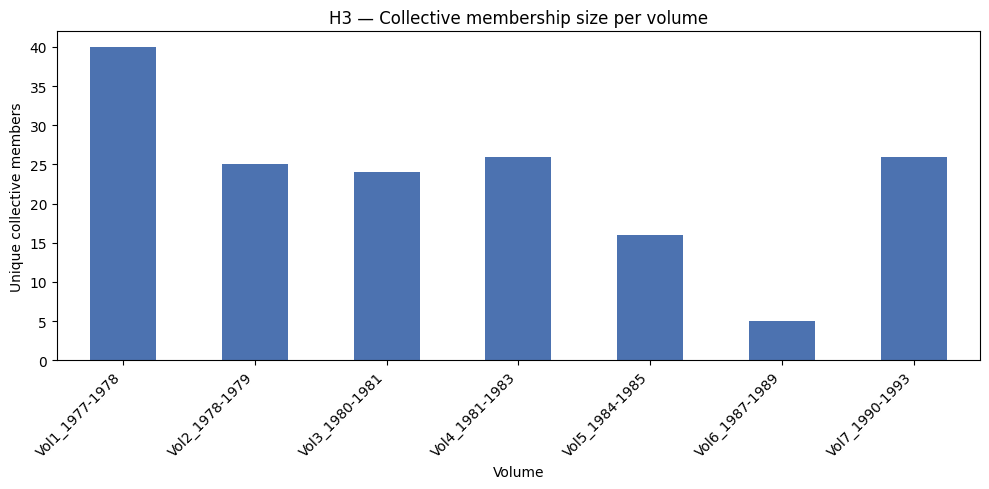

In [16]:
members_per_vol = df_coll_names.groupby("volume")["name"].nunique()
members_per_vol = members_per_vol.reindex([v for v in vol_order if v in members_per_vol.index])

print("Unique collective members per volume:")
print(members_per_vol)

fig, ax = plt.subplots(figsize=(10, 5))
members_per_vol.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Volume")
ax.set_ylabel("Unique collective members")
ax.set_title("H3 — Collective membership size per volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_collective_size.png")
plt.show()

#### 16. New Collective Members per Volume

New collective members per volume:
first_volume
Vol1_1977-1978    40
Vol2_1978-1979    18
Vol3_1980-1981    18
Vol4_1981-1983    16
Vol5_1984-1985     6
Vol6_1987-1989     5
Vol7_1990-1993    11
Name: count, dtype: int64


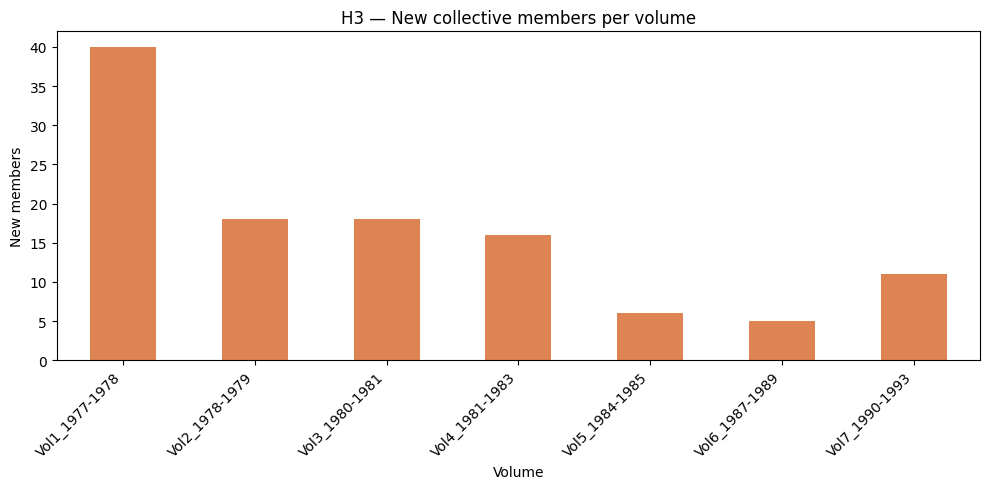

In [17]:
first_vol = df_coll_names.groupby("name")["issue"].min().reset_index()
first_vol["first_volume"] = first_vol["issue"].apply(get_volume)

new_members = first_vol["first_volume"].value_counts()
new_members = new_members.reindex([v for v in vol_order if v in new_members.index])

print("New collective members per volume:")
print(new_members)

fig, ax = plt.subplots(figsize=(10, 5))
new_members.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_xlabel("Volume")
ax.set_ylabel("New members")
ax.set_title("H3 — New collective members per volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_collective_members.png")
plt.show()

#### 17. Overlap Between Collective Members and Contributors

In [18]:
collective_set  = set(df_coll_names["name"].str.lower().str.strip())
contributor_set = set(df["person"].str.lower().str.strip())

overlap = collective_set & contributor_set

print(f"Collective members who also appear as contributors: {len(overlap)}")
print(f"Collective members only: {len(collective_set - contributor_set)}")
print(f"Contributors only: {len(contributor_set - collective_set)}")
print()
print("Overlapping names (sample):")
print(sorted(overlap)[:20])

Collective members who also appear as contributors: 46
Collective members only: 68
Contributors only: 1567

Overlapping names (sample):
['avis lang', 'carrie rickey', 'cynthia carr', 'denise green', 'diana agosta', 'edith becker', 'elizabeth hess', 'ellen lanyon', 'emma amos', 'estelle leontief', 'gail lineback', 'harmony hammond', 'ida applebroog', 'janet culbertson', 'joan braderman', 'josely carvalho', 'joyce kozloff', 'kathie brown', 'kay kenny', 'lenora champagne']


#### 18. Saving Results

In [20]:
volume_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h3_volume_frequency.csv", index=False)
first_appearance.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h3_first_appearance.csv", index=False)
df_coll_names.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h3_collective_names.csv", index=False)

It partially supports H3, but with a significant gap.

What it does well:
The contribution pattern side of H3 is well evidenced. High single-issue turnover (1,592 contributors appear only once), clear waves of new contributors (issue 17 alone brings 122 new names), and shifting collective membership all demonstrate that contribution patterns changed meaningfully across the magazine's run. This is solid structural evidence.

The critical gap:
H3 requires two things to coincide — theoretical orientation shifts AND contribution pattern changes. The notebook only establishes one side. It never actually connects the contributor waves to theoretical or thematic shifts. There's no analysis that says "when new contributors surged at issue 17, the themes also changed in X direction." The hypothesis is about correlation between two variables; only one variable is measured here.

The thematic emphasis claim is unaddressed:
H3 specifically mentions "changing thematic emphases associated with the magazine's rotating collectives." The notebook doesn't analyze themes at all — that would need to come from topic modeling, keyword frequency, or the NER data in notebook 09. Without it, the thematic half of H3 is asserted rather than tested.

The notebook's own summary overstates it:
The final interpretive cell declares H3 "supported," but what's actually shown is: contributors turned over frequently and in waves. That supports the mechanism proposed by H3 (rotating collectives = new contributors), but not the core claim that these changes coincide with theoretical shifts.

To fully answer H3 you'd need to cross-reference the new-contributor spikes (e.g., Vol7 surge) with the theoretical shift findings from H1/H2 and show they align temporally.

Is H3 supported? Partially. The notebook firmly establishes the contribution-pattern side — high turnover, waves of new contributors, rotating collective membership. But H3 requires two things to coincide: contribution shifts AND theoretical orientation shifts. This notebook only measures one variable. The "thematic emphases" half is never tested here — that would need to come from topic modeling or NER on paragraph text (your h1/h2 analysis). Without cross-referencing those findings temporally, H3 is asserted rather than fully demonstrated.

